In [1]:
import pandas as pd
import importlib

from UniversoActivos import UniversoActivosEstatico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
import Modelos
Modelos = importlib.reload(Modelos)
from Estrategia import EstrategiaMarkI
from Backtest import BacktestEngine

RandomForestModel = Modelos.RandomForestModel
XGBoostModel = Modelos.XGBoostModel

In [2]:
csv_path = r"pipelineJC\data\etfs_by_sector_industry_commodity.csv"

df = pd.read_csv(csv_path)
tickers = df["Ticker"].dropna().astype(str).str.strip().unique().tolist()

In [3]:
universo = UniversoActivosEstatico(tickers=tickers)
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio="mediana", ticker_indice="SPY")
modelo = XGBoostModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=15.0)
estrategia = EstrategiaMarkI(modelo=modelo, n_activos_obj=10, umbral_salida=22, umbral_target=0.7)

[*********************100%***********************]  40 of 40 completed
[*********************100%***********************]  40 of 40 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(Precio_Close=("Precio_Close", "last"), Volumen_USD=("Volumen_USD", "sum")).reset_index()
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  40 of 40 completed


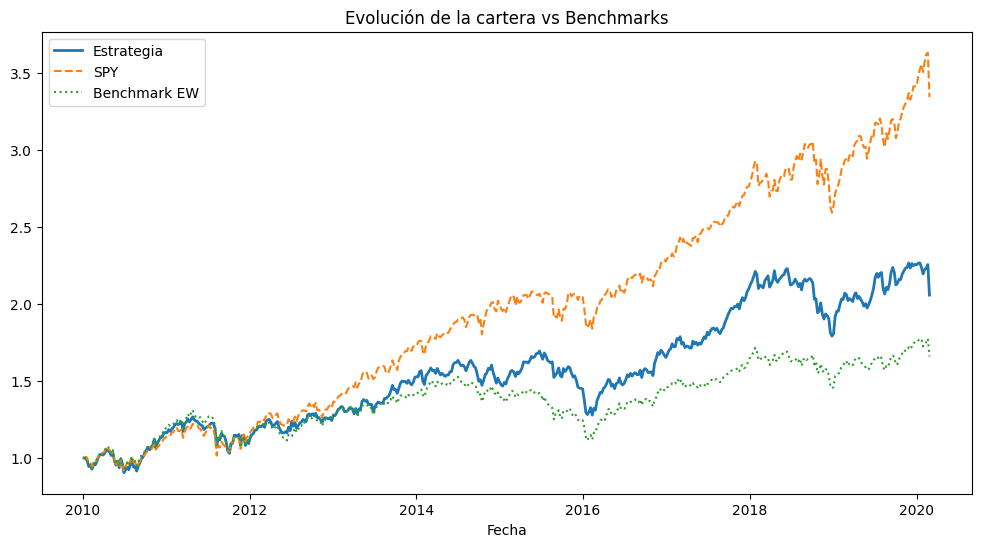

,Estrategia,SPY,Benchmark EW
Rentabilidad total,105.89%,234.59%,66.08%
Rentabilidad anualizada,7.36%,12.61%,5.11%
Volatilidad anualizada,14.81%,13.67%,13.43%
Sharpe,0.55,0.94,0.44
Sortino,0.77,1.31,0.60
Max Drawdown,-24.60%,-16.82%,-27.05%
Calmar,0.30,0.75,0.19
Win rate,56.71%,61.25%,56.71%
Mejor periodo,6.34%,7.23%,6.13%
Peor periodo,-10.20%,-11.00%,-10.33%


In [9]:
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2010-01-01",
    end_date="2020-03-01",
    len_ventana=5,
    nominal=10000000
)

engine.print_results(bmks=["SPY"], bmk_equal_weight=tickers)

In [8]:
import numpy as np
import pandas as pd
import itertools

from UniversoActivos import UniversoActivosEstatico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
from Modelos import XGBoostModel
from Estrategia import EstrategiaMarkI
from Backtest import BacktestEngine

import warnings
warnings.filterwarnings("ignore")


class CachedYFinanceProvider(YFinanceProvider):
    def __init__(self):
        self._cache_daily = {}
        self._cache_weekly = {}

    @staticmethod
    def _key(tickers, start_date, end_date):
        if isinstance(tickers, str):
            t = (tickers,)
        else:
            t = tuple(sorted(tickers))
        return (t, str(start_date), str(end_date))

    def download_prices_daily(self, tickers, start_date, end_date):
        k = self._key(tickers, start_date, end_date)
        if k not in self._cache_daily:
            self._cache_daily[k] = super().download_prices_daily(tickers, start_date, end_date)
        return self._cache_daily[k].copy()

    def download_prices_weekly(self, tickers, start_date, end_date):
        k = self._key(tickers, start_date, end_date)
        if k not in self._cache_weekly:
            self._cache_weekly[k] = super().download_prices_weekly(tickers, start_date, end_date)
        return self._cache_weekly[k].copy()


def perf_metrics(level_series, periods_per_year=52):
    r = level_series.dropna().pct_change().dropna()
    if len(r) == 0:
        return {"CAGR": np.nan, "Sharpe": np.nan, "MaxDD": np.nan, "Calmar": np.nan}
    total = (1 + r).prod() - 1
    ann = (1 + total) ** (periods_per_year / len(r)) - 1
    vol = r.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe = (r.mean() * periods_per_year) / vol if vol > 0 else np.nan
    eq = (1 + r).cumprod()
    dd = eq / eq.cummax() - 1
    mdd = dd.min()
    calmar = ann / abs(mdd) if mdd < 0 else np.nan
    return {"CAGR": ann, "Sharpe": sharpe, "MaxDD": mdd, "Calmar": calmar}


def run_config(cfg, tickers, proveedor, start_date="2020-01-01", end_date="2026-01-01", nominal=10_000_000):
    universo = UniversoActivosEstatico(tickers=tickers)
    fe = FeatureEngineer(criterio="mediana", ticker_indice="SPY")

    modelo = XGBoostModel(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        positive_class_weight=cfg["positive_class_weight"],
        random_state=42
    )

    estrategia = EstrategiaMarkI(
        modelo=modelo,
        n_activos_obj=cfg["n_activos_obj"],
        umbral_salida=cfg["umbral_salida"],
        umbral_target=cfg["umbral_target"]
    )

    engine = BacktestEngine(
        universo=universo,
        proveedor=proveedor,
        feature_engineer=fe,
        estrategia=estrategia,
        start_date=start_date,
        end_date=end_date,
        len_ventana=5,  # fijo para no agrandar el grid
        nominal=nominal
    )

    bt_df = engine._run()
    if bt_df.empty:
        out = {**cfg}
        out.update({"CAGR": np.nan, "Sharpe": np.nan, "MaxDD": np.nan, "Calmar": np.nan, "status": "empty_backtest"})
        return out

    serie = bt_df.set_index("Fecha")["Valor cartera"]
    serie = serie / serie.iloc[0]
    m = perf_metrics(serie)

    out = {**cfg}
    out.update(m)
    out["status"] = "ok"
    return out


# Grid compacto: 3*2*3*2*2*1 = 72 combos
grid = {
    "n_estimators": [120, 150, 180],       # en torno a 120-180
    "max_depth": [3, 4],                   # en torno a 3
    "positive_class_weight": [12.0, 15.0, 18.0],  # en torno a 15
    "n_activos_obj": [9, 11],              # en torno a 10
    "umbral_salida": [20, 24],             # en torno a 22
    "umbral_target": [0.70],               # fijo para no crecer el grid
}

all_cfgs = [dict(zip(grid.keys(), vals)) for vals in itertools.product(*grid.values())]
print(f"Combinaciones totales: {len(all_cfgs)}")

# Cap opcional (si quieres aun mas rapido)
MAX_RUNS = 60
rng = np.random.default_rng(42)
if len(all_cfgs) > MAX_RUNS:
    idx = rng.choice(len(all_cfgs), size=MAX_RUNS, replace=False)
    cfgs_to_run = [all_cfgs[i] for i in idx]
else:
    cfgs_to_run = all_cfgs

print(f"Combinaciones a ejecutar: {len(cfgs_to_run)}")

proveedor_cache = CachedYFinanceProvider()

rows = []
for i, cfg in enumerate(cfgs_to_run, 1):
    if i == 1 or i % 10 == 0 or i == len(cfgs_to_run):
        print(f"[{i}/{len(cfgs_to_run)}] {cfg}")
    rows.append(run_config(cfg, tickers=tickers, proveedor=proveedor_cache))

results = pd.DataFrame(rows)

leaderboard = (
    results
    .sort_values(by=["Sharpe", "CAGR", "MaxDD"], ascending=[False, False, True])
    .reset_index(drop=True)
)

display(
    leaderboard.head(20).style.format({
        "CAGR": "{:.2%}",
        "Sharpe": "{:.2f}",
        "MaxDD": "{:.2%}",
        "Calmar": "{:.2f}",
    })
)

[                       0%                       ]

Combinaciones totales: 72
Combinaciones a ejecutar: 60
[1/60] {'n_estimators': 120, 'max_depth': 3, 'positive_class_weight': 18.0, 'n_activos_obj': 11, 'umbral_salida': 20, 'umbral_target': 0.7}


[*********************100%***********************]  40 of 40 completed


[10/60] {'n_estimators': 150, 'max_depth': 3, 'positive_class_weight': 18.0, 'n_activos_obj': 9, 'umbral_salida': 20, 'umbral_target': 0.7}
[20/60] {'n_estimators': 120, 'max_depth': 4, 'positive_class_weight': 12.0, 'n_activos_obj': 11, 'umbral_salida': 20, 'umbral_target': 0.7}
[30/60] {'n_estimators': 120, 'max_depth': 4, 'positive_class_weight': 15.0, 'n_activos_obj': 11, 'umbral_salida': 24, 'umbral_target': 0.7}
[40/60] {'n_estimators': 180, 'max_depth': 3, 'positive_class_weight': 12.0, 'n_activos_obj': 9, 'umbral_salida': 24, 'umbral_target': 0.7}
[50/60] {'n_estimators': 180, 'max_depth': 3, 'positive_class_weight': 12.0, 'n_activos_obj': 11, 'umbral_salida': 24, 'umbral_target': 0.7}
[60/60] {'n_estimators': 180, 'max_depth': 4, 'positive_class_weight': 15.0, 'n_activos_obj': 11, 'umbral_salida': 24, 'umbral_target': 0.7}


,n_estimators,max_depth,positive_class_weight,n_activos_obj,umbral_salida,umbral_target,CAGR,Sharpe,MaxDD,Calmar,status
0,150,3,15.000000,9,20,0.700000,41.04%,2.60,-8.46%,4.85,ok
1,180,3,15.000000,11,24,0.700000,33.32%,2.40,-8.09%,4.12,ok
2,150,3,15.000000,11,20,0.700000,33.47%,2.36,-8.18%,4.09,ok
3,120,3,18.000000,9,24,0.700000,32.55%,2.36,-5.96%,5.46,ok
4,120,3,15.000000,11,20,0.700000,34.94%,2.27,-9.25%,3.78,ok
5,120,3,15.000000,9,20,0.700000,35.66%,2.26,-8.67%,4.11,ok
6,150,4,12.000000,11,20,0.700000,29.46%,2.26,-9.62%,3.06,ok
7,180,3,15.000000,9,20,0.700000,32.27%,2.22,-8.54%,3.78,ok
8,180,3,15.000000,11,20,0.700000,30.30%,2.20,-8.74%,3.47,ok
9,150,3,15.000000,11,24,0.700000,31.60%,2.18,-8.74%,3.62,ok
